##  Utforska och fördjupa er i neurala nätverk

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow import keras
from tensorflow.keras import layers

Dataset shape:
X shape: (70000, 28, 28)
y shape: (70000,)

Classes in dataset:
0: T-shirt/top
1: Trouser
2: Pullover
3: Dress
4: Coat
5: Sandal
6: Shirt
7: Sneaker
8: Bag
9: Ankle boot

Class distribution:
0    7000
1    7000
2    7000
3    7000
4    7000
5    7000
6    7000
7    7000
8    7000
9    7000
Name: count, dtype: int64


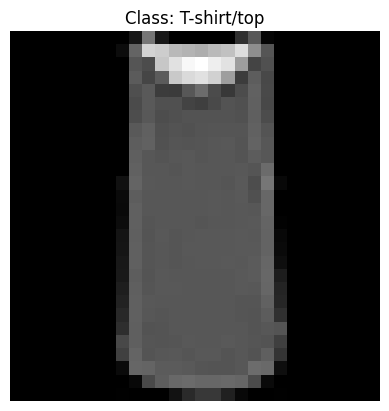

In [15]:
# --------------------------------------------
# 1. Load dataset
# --------------------------------------------

(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Combine train and test data
X = np.concatenate([X_train, X_test])
y = np.concatenate([y_train, y_test])

# --------------------------------------------
# 2. Explore dataset
# --------------------------------------------

print("Dataset shape:")
print("X shape:", X.shape)
print("y shape:", y.shape)

# Class names
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

print("\nClasses in dataset:")
for i, name in enumerate(class_names):
    print(f"{i}: {name}")

# Class distribution
class_distribution = pd.Series(y).value_counts().sort_index()

print("\nClass distribution:")
print(class_distribution)

# --------------------------------------------
# 3. Show sample image
# --------------------------------------------

plt.imshow(X[2], cmap="gray")
plt.title(f"Class: {class_names[y[2]]}")
plt.axis("off")
plt.show()



## Resultat 
- Datasetet består av 70 000 bilder från Fashion-MNIST.
- Datasetet innehåller totalt tio klasser, representerade av etiketterna 0–9. Klassfördelningen visar att varje klass innehåller exakt 7 000 bilder.
- Detta innebär att datasetet är balanserat och att det inte finns någon klassobalans som riskerar att påverka modellträningen negativt.

In [14]:
# --------------------------------------------
# 4. Train/Test split
# --------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

# --------------------------------------------
# 5. Normalize images
# --------------------------------------------

X_train = X_train / 255.0
X_test = X_test / 255.0

print("\nPixel range after normalization:")
print("Min:", X_train.min())
print("Max:", X_train.max())

# --------------------------------------------
# 6A. Reshape for Dense model
# --------------------------------------------

X_train_dense = X_train.reshape(-1, 784)
X_test_dense = X_test.reshape(-1, 784)

print("\nDense model shape:")
print("X_train_dense:", X_train_dense.shape)
print("X_test_dense:", X_test_dense.shape)

# --------------------------------------------
# 6B. Reshape for CNN model
# --------------------------------------------

X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

print("\nCNN model shape:")
print("X_train_cnn:", X_train_cnn.shape)
print("X_test_cnn:", X_test_cnn.shape)


Train shape: (56000, 28, 28)
Test shape: (14000, 28, 28)

Pixel range after normalization:
Min: 0.0
Max: 1.0

Dense model shape:
X_train_dense: (56000, 784)
X_test_dense: (14000, 784)

CNN model shape:
X_train_cnn: (56000, 28, 28, 1)
X_test_cnn: (14000, 28, 28, 1)
